In [13]:
import cv2
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os

In [ ]:
def visualize_images_with_bbox(data_dir, split_name, file_name):
    """
    Visualize single image with bounding boxes from YOLO format dataset.
    
    Args:
        data_dir: path to YOLO dataset directory (e.g., 'data_yolo')
        split_name: split name (train/valid/test)
        file_name: image file name (e.g., 'image_001.jpg')
    """
    data_path = Path(data_dir).resolve()  # Convert to absolute path
    
    
    img_path = data_path / split_name / 'images' / file_name
    label_path = data_path / split_name / 'labels' / (Path(file_name).stem + '.txt')
    yaml_path = data_path / 'data.yaml'
    
    # Check if files exist
    if not img_path.exists():
        print(f"Error: Image not found: {img_path}")
        return
    
    if not yaml_path.exists():
        print(f"Error: data.yaml not found: {yaml_path}")
        return
    
    # Load class names from data.yaml
    with open(yaml_path, 'r') as f:
        config = yaml.safe_load(f)
    class_names = config['names']
    
    # Generate colors for each class
    np.random.seed(42)
    colors = {}
    for class_id in class_names.keys():
        colors[class_id] = tuple(np.random.randint(50, 255, 3).tolist())
    
    # Read image
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Error: Cannot load image {img_path}")
        return
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_h, img_w = img.shape[:2]
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(img)
    ax.axis('off')
    
    # Read and draw bounding boxes
    bbox_count = 0
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                
                # Parse YOLO format
                class_id = int(parts[0])
                x_center = float(parts[1])
                y_center = float(parts[2])
                width = float(parts[3])
                height = float(parts[4])
                
                # Convert to pixel coordinates
                x_center_px = x_center * img_w
                y_center_px = y_center * img_h
                width_px = width * img_w
                height_px = height * img_h
                
                # Top-left corner
                x1 = x_center_px - width_px / 2
                y1 = y_center_px - height_px / 2
                
                # Get class info
                class_name = class_names.get(class_id, f"class_{class_id}")
                color = colors.get(class_id, (255, 0, 0))
                color_norm = tuple(c/255.0 for c in color)
                
                # Draw bounding box
                rect = patches.Rectangle(
                    (x1, y1), width_px, height_px,
                    linewidth=2,
                    edgecolor=color_norm,
                    facecolor='none'
                )
                ax.add_patch(rect)
                
                # Draw label
                ax.text(
                    x1, y1 - 5,
                    class_name,
                    fontsize=10,
                    color='white',
                    weight='bold',
                    bbox=dict(
                        facecolor=color_norm,
                        alpha=0.8,
                        edgecolor='none',
                        boxstyle='round,pad=0.5'
                    )
                )
                
                bbox_count += 1
    else:
        print(f"Warning: Label file not found: {label_path}")
    
    # Set title
    ax.set_title(f"{file_name} - {bbox_count} objects", fontsize=14, pad=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nImage: {file_name}")
    print(f"Size: {img_w}x{img_h}")
    print(f"Objects: {bbox_count}")

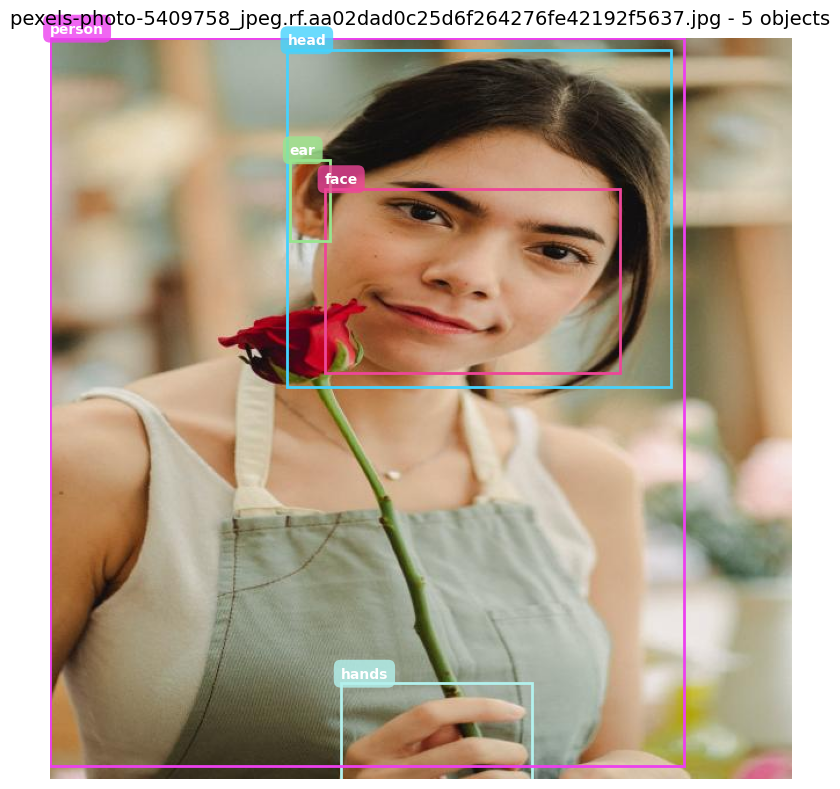


Image: pexels-photo-5409758_jpeg.rf.aa02dad0c25d6f264276fe42192f5637.jpg
Size: 640x640
Objects: 5


In [21]:
visualize_images_with_bbox(data_dir='/workspace/data_yolo',split_name='test',file_name='pexels-photo-5409758_jpeg.rf.aa02dad0c25d6f264276fe42192f5637.jpg')